# Задача 1. Лингвистика и синтаксический разбор текстовых данных

**Дисциплина:** Методы обработки семантической информации  
**Тема:** Поиск подлежащих и сказуемых в новостных текстах, анализ их совместных употреблений и визуализация результатов.

Этот ноутбук подготовлен под датасет **Lenta.ru** с Kaggle, но также умеет работать и с другими файлами новостей, если рядом лежит `news.csv`.

## Что важно перед запуском

1. Ноутбук сначала ищет один из файлов:
   - `lenta-ru-news.csv.bz2`
   - `lenta-ru-news.csv`
   - `news.csv`
   - `demo_news.csv`
2. Для большого корпуса **Lenta.ru** по умолчанию берётся только часть строк, чтобы первый запуск в VS Code не зависал.
3. После успешной проверки можно увеличить число обрабатываемых текстов или убрать ограничение совсем.

In [1]:
# При первом запуске раскомментируйте и выполните эти команды один раз:
import sys
!{sys.executable} -m pip install pandas matplotlib seaborn spacy openpyxl
!{sys.executable} -m spacy download ru_core_news_sm


DEPRECATION: Loading egg at /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/vboxapi-1-py3.11.egg is deprecated. pip 23.3 will enforce this behaviour change. A possible replacement is to use pip for package installation..

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
DEPRECATION: Loading egg at /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/vboxapi-1-py3.11.egg is deprecated. pip 23.3 will enforce this behaviour change. A possible replacement is to use pip for package installation..
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 2.7 MB/s eta 0:00:0000:0100:01m
  Obtaining dependency information for pymorphy3>=1.0.0 from https://files.pythonhosted.org/packages/18/4b/59bac03278033e293d1405ed42fb6c6252c25f40c50f509c615caeaa3b71/pymorphy3-2.0.6-py3-none-any.whl.metadata
  Obtaining dependency information for dawg2-python>=0.8.0 from https://files.p

In [2]:
import os
import re
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from IPython.display import display


## Настройки запуска

- `LOAD_NROWS` — сколько строк считывать из файла.  
  Для корпуса Lenta.ru лучше начать с **20 000** или **50 000** строк.
- `MAX_TEXTS_TO_PROCESS` — сколько непустых текстов реально отправлять в spaCy.

In [3]:
LOAD_NROWS = 20000          # None -> читать весь файл (для Lenta это тяжело)
MAX_TEXTS_TO_PROCESS = 10000  # None -> обрабатывать все считанные тексты
RANDOM_STATE = 42

## Поиск файла с данными

In [4]:
DATA_PATH_CANDIDATES = [
    Path("lenta-ru-news.csv.bz2"),
    Path("lenta-ru-news.csv"),
    Path("news.csv"),
    Path("dataset/lenta-ru-news.csv.bz2"),
    Path("dataset/lenta-ru-news.csv"),
    Path("dataset/news.csv"),
    Path("data/lenta-ru-news.csv.bz2"),
    Path("data/lenta-ru-news.csv"),
    Path("data/news.csv"),
    Path("demo_news.csv"),
]

DATA_PATH = next((path for path in DATA_PATH_CANDIDATES if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Файл датасета не найден. Положите рядом с ноутбуком "
        "'lenta-ru-news.csv.bz2', 'lenta-ru-news.csv' или 'news.csv'."
    )

print(f"Найден файл: {DATA_PATH}")

Найден файл: lenta-ru-news.csv


## Загрузка датасета

Для CSV-файлов предусмотрены:
- автоматическое определение сжатия (`.bz2`);
- несколько популярных кодировок;
- попытка чтения как с `,`, так и с `;`.

In [5]:
def load_table(path: Path, nrows=None) -> pd.DataFrame:
    suffixes = [s.lower() for s in path.suffixes]
    is_csv_like = ".csv" in suffixes or path.suffix.lower() in {".csv", ".bz2"}
    compression = "infer"

    if is_csv_like:
        encodings = ["utf-8", "utf-8-sig", "cp1251", "windows-1251", "latin-1"]
        seps = [",", ";"]

        last_error = None
        for enc in encodings:
            for sep in seps:
                try:
                    return pd.read_csv(
                        path,
                        encoding=enc,
                        sep=sep,
                        compression=compression,
                        low_memory=False,
                        nrows=nrows,
                    )
                except Exception as e:
                    last_error = e
        raise last_error

    if path.suffix.lower() in {".xls", ".xlsx"}:
        return pd.read_excel(path)

    if path.suffix.lower() == ".json":
        return pd.read_json(path)

    if path.suffix.lower() == ".jsonl":
        return pd.read_json(path, lines=True)

    raise ValueError(f"Неподдерживаемый формат файла: {path.name}")

In [6]:
df = load_table(DATA_PATH, nrows=LOAD_NROWS)

print("Форма таблицы:", df.shape)
print("Колонки:", df.columns.tolist())
display(df.head(3))

Форма таблицы: (20000, 6)
Колонки: ['url', 'title', 'text', 'topic', 'tags', 'date']


,url,title,text,topic,tags,date
0,https://lenta.ru/news/1914/09/16/hungarnn/,1914. Русские войска вступили в пределы Венгрии,Бои у Сопоцкина и Друскеник закончились отступ...,Библиотека,Первая мировая,1914/09/16
1,https://lenta.ru/news/1914/09/16/lermontov/,1914. Празднование столетия М.Ю. Лермонтова от...,"Министерство народного просвещения, в виду про...",Библиотека,Первая мировая,1914/09/16
2,https://lenta.ru/news/1914/09/17/nesteroff/,1914. Das ist Nesteroff!,"Штабс-капитан П. Н. Нестеров на днях, увидев в...",Библиотека,Первая мировая,1914/09/17


## Поиск текстовой колонки

Для Lenta.ru обычно подходит колонка `text`.  
Если её нет, ноутбук попробует найти одну из типовых колонок автоматически.

In [7]:
TEXT_CANDIDATES = [
    "text", "content", "article", "full_text", "news_text", "body", "description"
]
TITLE_CANDIDATES = ["title", "headline", "name"]

def detect_text_column(frame: pd.DataFrame) -> str:
    lower_map = {str(col).lower(): col for col in frame.columns}

    for candidate in TEXT_CANDIDATES:
        if candidate in lower_map:
            return lower_map[candidate]

    # fallback: ищем строковую колонку с самым длинным средним текстом
    text_like_cols = []
    for col in frame.columns:
        if pd.api.types.is_string_dtype(frame[col]) or frame[col].dtype == "object":
            sample = frame[col].dropna().astype(str).head(300)
            if len(sample) == 0:
                continue
            avg_len = sample.str.len().mean()
            if avg_len and avg_len > 40:
                text_like_cols.append((col, avg_len))

    if text_like_cols:
        text_like_cols.sort(key=lambda x: x[1], reverse=True)
        return text_like_cols[0][0]

    raise ValueError(
        "Не удалось автоматически определить колонку с текстом. "
        f"Доступные колонки: {frame.columns.tolist()}"
    )

text_col = detect_text_column(df)
print("Выбрана колонка с текстом:", text_col)

Выбрана колонка с текстом: text


In [8]:
texts = (
    df[text_col]
    .dropna()
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

texts = texts[texts != ""]

if MAX_TEXTS_TO_PROCESS is not None and len(texts) > MAX_TEXTS_TO_PROCESS:
    texts = texts.sample(n=MAX_TEXTS_TO_PROCESS, random_state=RANDOM_STATE)

texts = texts.reset_index(drop=True)

if texts.empty:
    raise ValueError("После очистки в выбранной колонке не осталось текстов для обработки.")

print("Количество текстов для обработки:", len(texts))
print()
print("Пример текста:")
print(texts.iloc[0][:700])

Количество текстов для обработки: 10000

Пример текста:
В Шали сегодня было обнаруженно взрывное устройство мощностью около пяти килограммов в тротиловом эквиваленте. Бандиты установили его в здании детского сада, расположенного в непосредственной близости от временного отдела внутренних дел. Как сообщает ИТАР-ТАСС, направленный взрыв заложенного заряда должен был разрушить здание милиции. Его жертвами могли стать не только милиционеры, но и местное население. Обнаруженное взрывное устройство вывезено в безопасное место и уничтожено. Как сообщили РИА "Новости" во временном пресс-центре МВД России на Северном Кавказе, боевики не прекращают попыток нападения на колонны федеральных сил и минирования местности в районах дислокаций милицейских подразд


## Загрузка модели spaCy

In [9]:
try:
    nlp = spacy.load("ru_core_news_sm")
    print("Модель ru_core_news_sm успешно загружена")
except OSError as e:
    raise OSError(
        "Не найдена модель ru_core_news_sm. Установите её командой:\n"
        "python -m spacy download ru_core_news_sm"
    ) from e

Модель ru_core_news_sm успешно загружена


## Правила извлечения подлежащего и сказуемого

В этой работе используются такие упрощённые правила:

- **подлежащее**: зависимости `nsubj`, `nsubj:pass`, `csubj`;
- **сказуемое**: корень предложения (`ROOT`), если это глагол, вспомогательный глагол
  или краткое/полное прилагательное в роли предиката;
- для единообразия сохраняются **леммы** слов.

Такое упрощение хорошо подходит для новостных текстов и даёт понятный учебный результат.

In [10]:
VERB_LIKE_POS = {"VERB", "AUX"}
SUBJ_DEPS = {"nsubj", "nsubj:pass", "csubj"}
SUBJ_POS = {"NOUN", "PROPN", "PRON"}

def normalize_token(token) -> str:
    lemma = token.lemma_.strip().lower()
    if not lemma or lemma == "-pron-":
        lemma = token.text.strip().lower()
    lemma = lemma.replace("ё", "е")
    lemma = re.sub(r"\s+", " ", lemma)
    return lemma

def is_valid_subject(token) -> bool:
    return token.dep_ in SUBJ_DEPS and token.pos_ in SUBJ_POS

def is_valid_predicate(token) -> bool:
    if token.dep_ != "ROOT":
        return False
    if token.pos_ in VERB_LIKE_POS:
        return True
    if token.pos_ == "ADJ":
        return True
    return False

def expand_conj_subjects(subject_token):
    subjects = [subject_token]
    for child in subject_token.children:
        if child.dep_ == "conj" and child.pos_ in SUBJ_POS:
            subjects.append(child)

    result = []
    seen = set()
    for token in subjects:
        value = normalize_token(token)
        if value and value not in seen:
            seen.add(value)
            result.append(value)
    return result

def extract_pairs_from_sentence(sent):
    root = next((token for token in sent if is_valid_predicate(token)), None)
    if root is None:
        return []

    predicate = normalize_token(root)
    if not predicate:
        return []

    subjects = []
    for token in sent:
        if is_valid_subject(token) and token.head == root:
            subjects.extend(expand_conj_subjects(token))

    subjects = sorted(set(subjects))
    return [(subject, predicate) for subject in subjects]

In [11]:
# Мини-проверка на простых примерах
examples = [
    "Президент заявил о новых мерах поддержки экономики.",
    "Правительство приняло решение о расширении программы субсидий.",
    "Компания сообщила о росте прибыли по итогам квартала.",
    "Министр и губернатор обсудили проект."
]

for sentence in examples:
    doc = nlp(sentence)
    pairs = []
    for sent in doc.sents:
        pairs.extend(extract_pairs_from_sentence(sent))
    print(sentence)
    print("->", pairs)
    print("-" * 80)

Президент заявил о новых мерах поддержки экономики.
-> [('президент', 'заявить')]
--------------------------------------------------------------------------------
Правительство приняло решение о расширении программы субсидий.
-> [('правительство', 'принять')]
--------------------------------------------------------------------------------
Компания сообщила о росте прибыли по итогам квартала.
-> [('компания', 'сообщить')]
--------------------------------------------------------------------------------
Министр и губернатор обсудили проект.
-> [('губернатор', 'обсудить'), ('министр', 'обсудить')]
--------------------------------------------------------------------------------


## Извлечение пар из корпуса

Для ускорения используется `nlp.pipe`, а не поштучный вызов `nlp(text)` для каждого текста.

In [12]:
all_pairs = []
example_rows = []
total_texts = 0
total_sentences = 0

for doc in nlp.pipe(texts.tolist(), batch_size=32):
    total_texts += 1

    if total_texts % 1000 == 0:
        print(f"Обработано текстов: {total_texts}")

    for sent in doc.sents:
        sent_text = sent.text.strip()
        if not sent_text:
            continue

        total_sentences += 1
        pairs = extract_pairs_from_sentence(sent)
        all_pairs.extend(pairs)

        for subject, predicate in pairs:
            if len(example_rows) < 30:
                example_rows.append(
                    {
                        "sentence": sent_text,
                        "subject": subject,
                        "predicate": predicate,
                    }
                )

print()
print("Всего обработано текстов:", total_texts)
print("Всего обработано предложений:", total_sentences)
print("Всего найдено пар (подлежащее, сказуемое):", len(all_pairs))

Обработано текстов: 1000
Обработано текстов: 2000
Обработано текстов: 3000
Обработано текстов: 4000
Обработано текстов: 5000
Обработано текстов: 6000
Обработано текстов: 7000
Обработано текстов: 8000
Обработано текстов: 9000
Обработано текстов: 10000

Всего обработано текстов: 10000
Всего обработано предложений: 83705
Всего найдено пар (подлежащее, сказуемое): 79073


In [13]:
examples_df = pd.DataFrame(example_rows)
print("Примеры извлечённых пар:")
display(examples_df.head(15))

Примеры извлечённых пар:


,sentence,subject,predicate
0,В Шали сегодня было обнаруженно взрывное устро...,устройство,было
1,"Бандиты установили его в здании детского сада,...",бандит,установить
2,"Как сообщает ИТАР-ТАСС, направленный взрыв зал...",взрыв,должный
3,Обнаруженное взрывное устройство вывезено в бе...,устройство,вывезти
4,"Как сообщили РИА ""Новости"" во временном пресс-...",боевик,прекращать
5,В Октябрьском районе Грозного при проведении о...,сотрудник,обнаружить
6,"По данным правоохранительных органов, в окрест...",сотрудник,уничтожить
7,В Урус-Мартане в нежилом доме милиционеры обна...,милиционер,обнаружить
8,Восемь реактивных снарядов к гранатомету обнар...,снаряд,обнаружить
9,Снаряды уничтожены.,снаряд,уничтожить


## Подсчёт частот совместных употреблений

In [14]:
pair_counter = Counter(all_pairs)
subject_counter = Counter(subject for subject, _ in all_pairs)
predicate_counter = Counter(predicate for _, predicate in all_pairs)

print("Уникальных пар:", len(pair_counter))
print("Уникальных подлежащих:", len(subject_counter))
print("Уникальных сказуемых:", len(predicate_counter))

Уникальных пар: 49850
Уникальных подлежащих: 9023
Уникальных сказуемых: 4378


In [15]:
top_100_pairs = pair_counter.most_common(100)

result_df = pd.DataFrame(top_100_pairs, columns=["pair", "frequency"])
if not result_df.empty:
    result_df["subject"] = result_df["pair"].apply(lambda x: x[0])
    result_df["predicate"] = result_df["pair"].apply(lambda x: x[1])
    result_df = result_df[["subject", "predicate", "frequency"]]
else:
    result_df = pd.DataFrame(columns=["subject", "predicate", "frequency"])

display(result_df.head(20))

,subject,predicate,frequency
0,дело,возбудить,264
1,человек,погибнуть,233
2,решение,принять,232
3,представитель,заявить,182
4,он,заявить,177
5,речь,идти,166
6,он,отметить,160
7,он,сообщить,145
8,он,подчеркнуть,121
9,взрыв,произойти,120


## Визуализация результатов

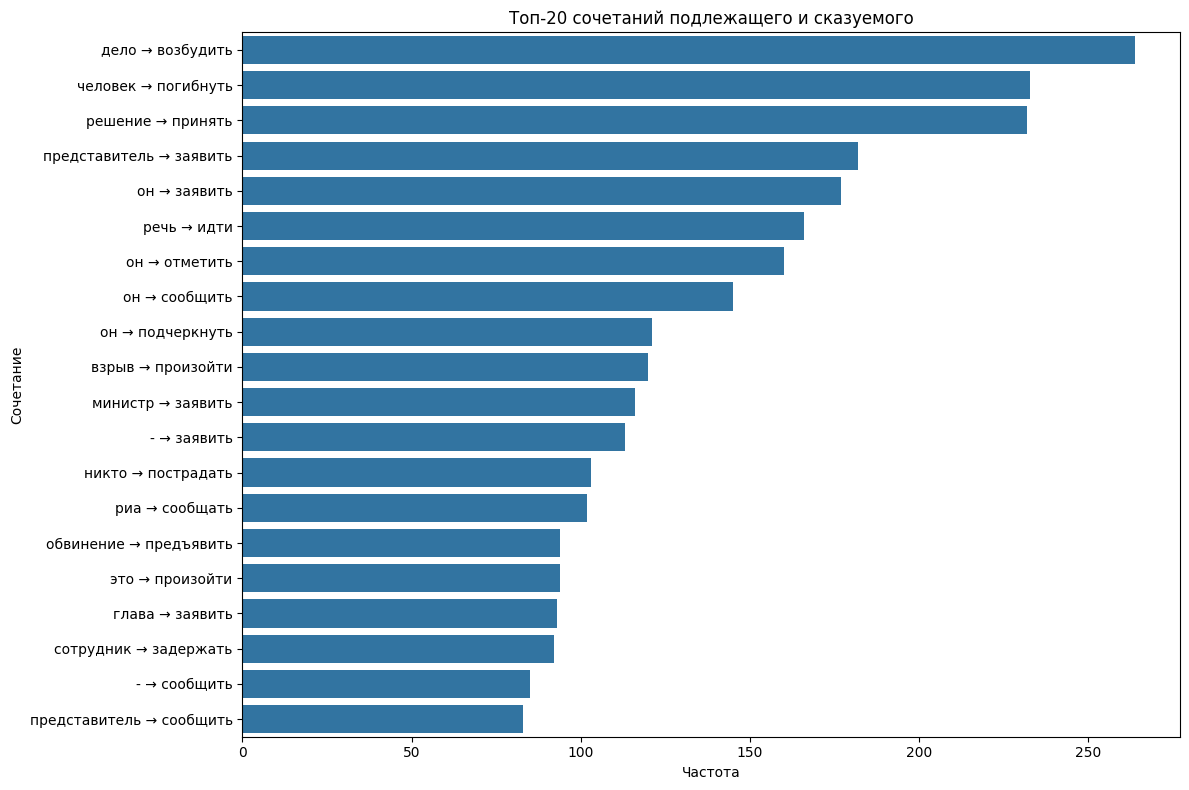

In [16]:
top20 = result_df.head(20).copy()

if not top20.empty:
    top20["pair_label"] = top20["subject"] + " → " + top20["predicate"]

    plt.figure(figsize=(12, 8))
    sns.barplot(data=top20, x="frequency", y="pair_label")
    plt.title("Топ-20 сочетаний подлежащего и сказуемого")
    plt.xlabel("Частота")
    plt.ylabel("Сочетание")
    plt.tight_layout()
    plt.show()
else:
    print("Недостаточно данных для графика топ-20.")

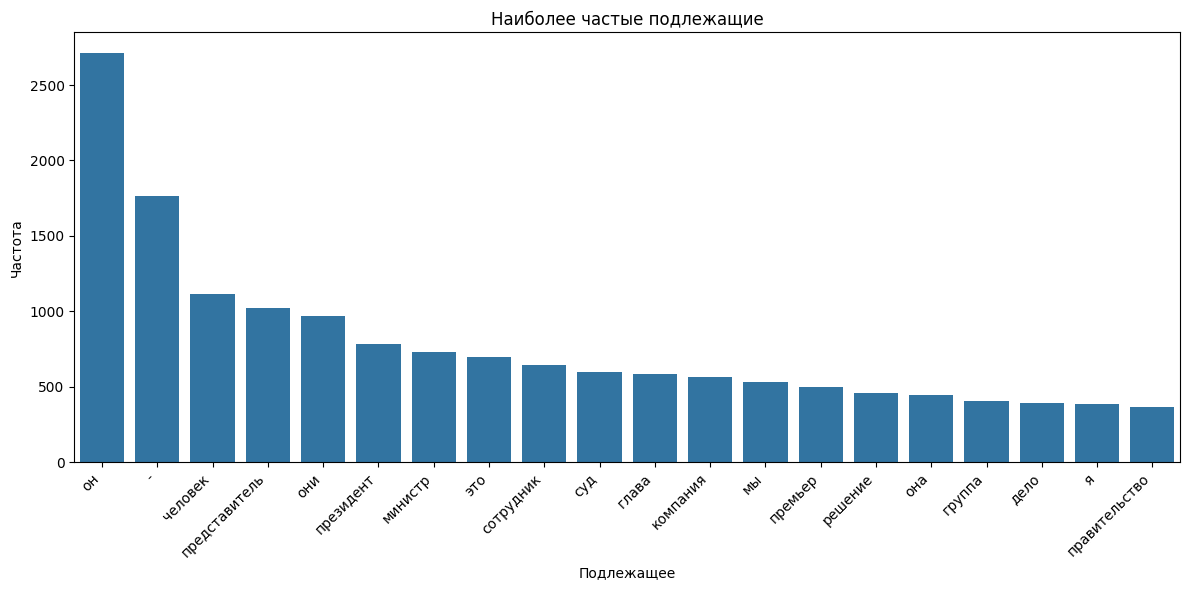

In [17]:
subject_df = pd.DataFrame(subject_counter.most_common(20), columns=["subject", "frequency"])

if not subject_df.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=subject_df, x="subject", y="frequency")
    plt.title("Наиболее частые подлежащие")
    plt.xlabel("Подлежащее")
    plt.ylabel("Частота")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Недостаточно данных для графика подлежащих.")

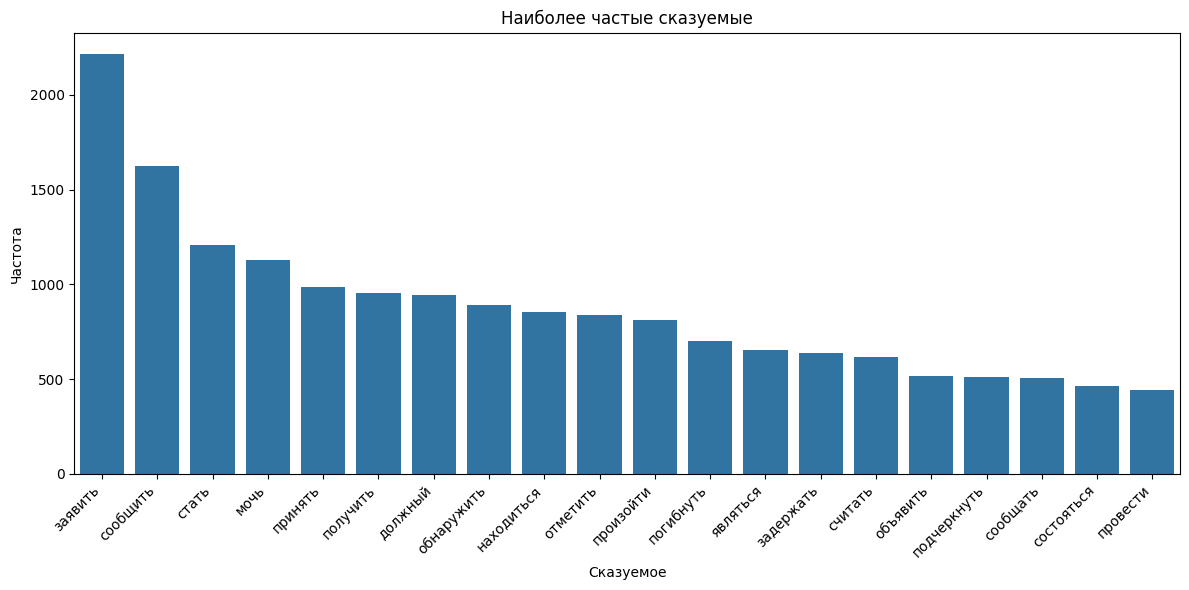

In [18]:
predicate_df = pd.DataFrame(predicate_counter.most_common(20), columns=["predicate", "frequency"])

if not predicate_df.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=predicate_df, x="predicate", y="frequency")
    plt.title("Наиболее частые сказуемые")
    plt.xlabel("Сказуемое")
    plt.ylabel("Частота")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Недостаточно данных для графика сказуемых.")

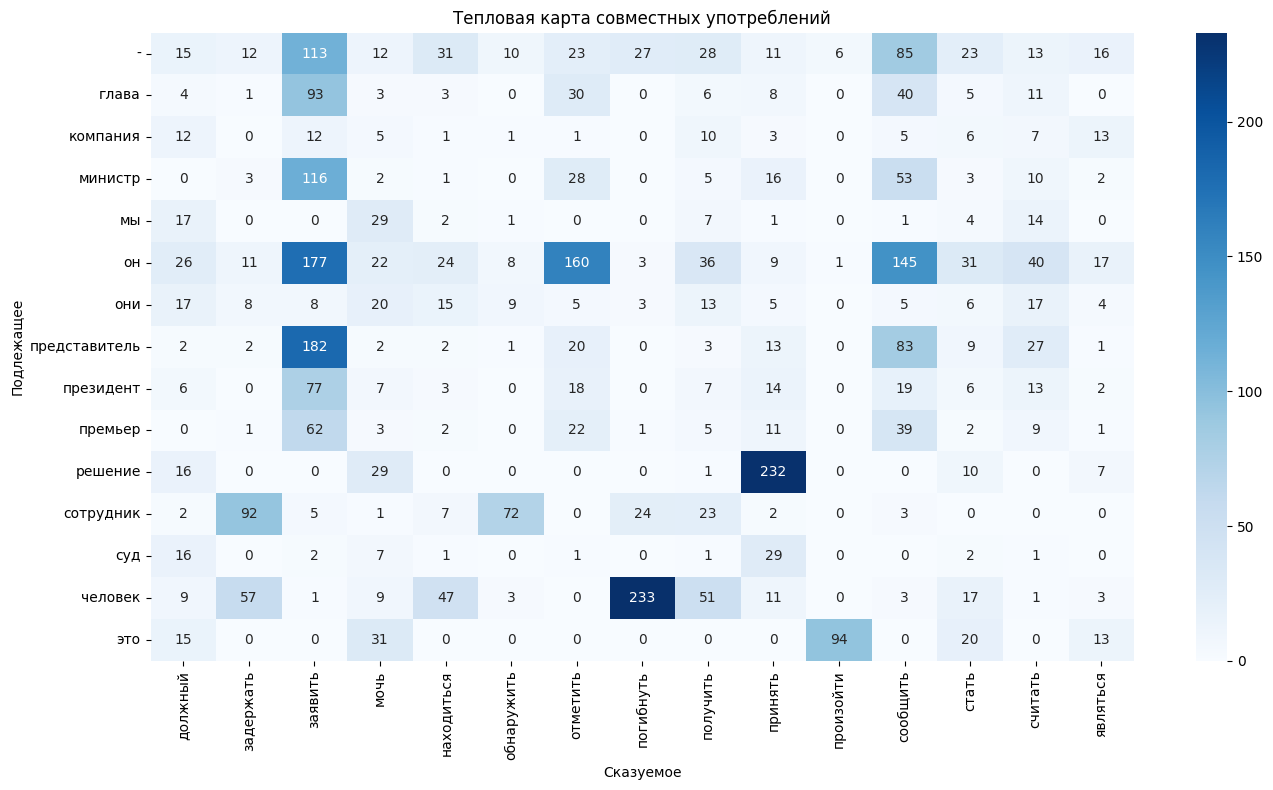

In [19]:
top_subjects = [subject for subject, _ in subject_counter.most_common(15)]
top_predicates = [predicate for predicate, _ in predicate_counter.most_common(15)]

heatmap_pairs = [
    (subject, predicate, freq)
    for (subject, predicate), freq in pair_counter.items()
    if subject in top_subjects and predicate in top_predicates
]

heatmap_df = pd.DataFrame(heatmap_pairs, columns=["subject", "predicate", "frequency"])

if not heatmap_df.empty:
    pivot_df = heatmap_df.pivot_table(
        index="subject",
        columns="predicate",
        values="frequency",
        fill_value=0,
    )

    plt.figure(figsize=(14, 8))
    sns.heatmap(pivot_df, annot=True, fmt=".0f", cmap="Blues")
    plt.title("Тепловая карта совместных употреблений")
    plt.xlabel("Сказуемое")
    plt.ylabel("Подлежащее")
    plt.tight_layout()
    plt.show()
else:
    print("Недостаточно данных для тепловой карты.")

## Сохранение результатов

После выполнения будут сохранены:
- `subject_predicate_top100.csv`
- `top_subjects.csv`
- `top_predicates.csv`
- `subject_predicate_examples.csv`

In [20]:
result_df.to_csv("subject_predicate_top100.csv", index=False, encoding="utf-8-sig")
subject_df.to_csv("top_subjects.csv", index=False, encoding="utf-8-sig")
predicate_df.to_csv("top_predicates.csv", index=False, encoding="utf-8-sig")
examples_df.to_csv("subject_predicate_examples.csv", index=False, encoding="utf-8-sig")

print("Файлы успешно сохранены.")

Файлы успешно сохранены.


## Краткий вывод

После запуска ноутбука на корпусе новостей будут получены:
- список до 100 наиболее частотных пар **(подлежащее, сказуемое)**;
- распределения частот для подлежащих и сказуемых;
- тепловая карта совместных употреблений.

Для новостного дискурса обычно характерно преобладание институциональных субъектов
(например, *президент*, *министр*, *компания*, *суд*, *правительство*) и глаголов
сообщения, решения или оценки (*заявить*, *сообщить*, *принять*, *отметить*, *обсудить*).